# Brain Tumor Segmentation

## Model Training 

The Model Training is done in Google Colab. Therefore the needed modules has to be installed and imported. 

In [ ]:
!pip install fastai
!pip install SimpleITK
!pip install pydicom
!pip install kornia
!pip install torch
!pip install nnunetv2
!pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 MB 32.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.6/178.6 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 41.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━

  Cloning https://github.com/FabianIsensee/hiddenlayer.git to /tmp/pip-req-build-nr_fg8yu
  Running command git clone --filter=blob:none --quiet https://github.com/FabianIsensee/hiddenlayer.git /tmp/pip-req-build-nr_fg8yu
  Resolved https://github.com/FabianIsensee/hiddenlayer.git to commit b7263b6dc4569da1b6dea5964e1eac78fa32fa77
  Preparing metadata (setup.py) ... done
  Created wheel for hiddenlayer: filename=hiddenlayer-0.2-py3-none-any.whl size=20003 sha256=76472c6bc0e8305607509ae0eaacaa6a11656eaff7fc83314f70f38e0e5a5fb2
  Stored in directory: /tmp/pip-ephem-wheel-cache-trqd9b2o/wheels/55/0e/e3/fdf2f92789305c0e320e0ab01f27fd4b757b1bb01c07d532c4
Successfully built hiddenlayer


In [ ]:
import os
from fastai.vision.all import *
import SimpleITK as sitk
import shutil
from tqdm import tqdm
import nibabel as nib
from fastai.medical.imaging import *
import nnunetv2
import torch

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
print(torch.cuda.is_available())

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

True
cuda:0


nnunetv2 is set up with 1000 epochs for a training. As this will take too long, we will shorten it to 100.

In [ ]:
%%bash
export nnUNet_raw="/content/drive/MyDrive/nnunet/nnUNet_raw"
export nnUNet_preprocessed="/content/drive/MyDrive/nnunet/nnUNet_preprocessed"
export nnUNet_results="/content/drive/MyDrive/nnunet/nnUNet_results"

nnUNetv2_train Dataset001-REMIND 2d 0 -tr nnUNetTrainerBenchmark_5epochs
nnUNetv2_train Dataset001-REMIND 3d_fullres 0 -tr nnUNetTrainerBenchmark_5epochs
nnUNetv2_train Dataset001-REMIND 2d 0 -tr nnUNetTrainerBenchmark_5epochs_noDataLoading
nnUNetv2_train Dataset001-REMIND 3d_fullres 0 -tr nnUNetTrainerBenchmark_5epochs_noDataLoading

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################


This is the configuration used by this training:
Configuration name: 2d
 {'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 57, 'patch_size': [256, 224], 'median_image_size_in_voxels': [254.0, 202.0], 'spacing': [1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'UNet_class_name': 'PlainConvUNet', 'UNet_base_num_features': 32, 'n_conv_per_stage_encoder': [2, 2, 2, 2, 2, 2], 'n_conv_per_stage_decoder': [2, 2, 2, 2, 2], 'num_pool_per_axis': [5, 5], 'pool_op_kernel_sizes': [[1, 1], [2, 2

/usr/local/lib/python3.10/dist-packages/torch/onnx/symbolic_helper.py:1513: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/onnx/symbolic_helper.py:1513: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/onnx/symbolic_helper.py:1513: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/onnx/symbolic_helper.py:1513: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  warnings.warn(


In [ ]:
import os
os.environ['nnUNet_raw'] = "/content/drive/MyDrive/nnunet/nnUNet_raw"
os.environ['nnUNet_preprocessed'] =  "/content/drive/MyDrive/nnunet/nnUNet_preprocessed"
os.environ['nnUNet_results'] = "/content/drive/MyDrive/nnunet/nnUNet_results"

# Verify dataset integrity has to be executed only the first time you are pre-processing the data
# After successful plan and preprocessing
!nnUNetv2_train Dataset001-REMIND 3d_fullres 0 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 1 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 2 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 3 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 4 --npz

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################


This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [112, 160, 128], 'median_image_size_in_voxels': [192.0, 254.0, 202.0], 'spacing': [1.0, 1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'UNet_class_name': 'PlainConvUNet', 'UNet_base_num_features': 32, 'n_conv_per_stage_encoder': [2, 2, 2, 2, 2, 2], 'n_conv_per_stage_decoder': [2, 2, 2, 2, 2], 'num_pool_per_axis': [4, 5, 5], 'po

In [ ]:
%%bash
export nnUNet_raw="/content/drive/MyDrive/nnunet/nnUNet_raw"
export nnUNet_preprocessed="/content/drive/MyDrive/nnunet/nnUNet_preprocessed"
export nnUNet_results="/content/drive/MyDrive/nnunet/nnUNet_results"

nnUNetv2_train Dataset001-REMIND 3d_fullres 1 --npz



Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################


This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [112, 160, 128], 'median_image_size_in_voxels': [192.0, 254.0, 202.0], 'spacing': [1.0, 1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'UNet_class_name': 'PlainConvUNet', 'UNet_base_num_features': 32, 'n_conv_per_stage_encoder': [2, 2, 2, 2, 2, 2], 'n_conv_per_stage_decoder': [2, 2, 2, 2, 2], 'num_pool_per_axis': [4, 5, 5], 'po

/usr/local/lib/python3.10/dist-packages/torch/onnx/symbolic_helper.py:1513: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  warnings.warn(


In [ ]:
import os
os.environ['nnUNet_raw'] = "/content/drive/MyDrive/nnunet/nnUNet_raw"
os.environ['nnUNet_preprocessed'] =  "/content/drive/MyDrive/nnunet/nnUNet_preprocessed"
os.environ['nnUNet_results'] = "/content/drive/MyDrive/nnunet/nnUNet_results"

# Verify dataset integrity has to be executed only the first time you are pre-processing the data
# After successful plan and preprocessing
!nnUNetv2_train Dataset001-REMIND 3d_fullres 2 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 1 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 2 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 3 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 4 --npz

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################


This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [112, 160, 128], 'median_image_size_in_voxels': [192.0, 254.0, 202.0], 'spacing': [1.0, 1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'UNet_class_name': 'PlainConvUNet', 'UNet_base_num_features': 32, 'n_conv_per_stage_encoder': [2, 2, 2, 2, 2, 2], 'n_conv_per_stage_decoder': [2, 2, 2, 2, 2], 'num_pool_per_axis': [4, 5, 5], 'po

In [ ]:
import os
os.environ['nnUNet_raw'] = "/content/drive/MyDrive/nnunet/nnUNet_raw"
os.environ['nnUNet_preprocessed'] =  "/content/drive/MyDrive/nnunet/nnUNet_preprocessed"
os.environ['nnUNet_results'] = "/content/drive/MyDrive/nnunet/nnUNet_results"

# Verify dataset integrity has to be executed only the first time you are pre-processing the data
# After successful plan and preprocessing
!nnUNetv2_train Dataset001-REMIND 3d_fullres 2 --npz --c
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 1 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 2 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 3 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 4 --npz

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################


This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [112, 160, 128], 'median_image_size_in_voxels': [192.0, 254.0, 202.0], 'spacing': [1.0, 1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'UNet_class_name': 'PlainConvUNet', 'UNet_base_num_features': 32, 'n_conv_per_stage_encoder': [2, 2, 2, 2, 2, 2], 'n_conv_per_stage_decoder': [2, 2, 2, 2, 2], 'num_pool_per_axis': [4, 5, 5], 'po

In [ ]:
import os
os.environ['nnUNet_raw'] = "/content/drive/MyDrive/nnunet/nnUNet_raw"
os.environ['nnUNet_preprocessed'] =  "/content/drive/MyDrive/nnunet/nnUNet_preprocessed"
os.environ['nnUNet_results'] = "/content/drive/MyDrive/nnunet/nnUNet_results"

# Verify dataset integrity has to be executed only the first time you are pre-processing the data
# After successful plan and preprocessing
!nnUNetv2_train Dataset001-REMIND 3d_fullres 3 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 1 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 2 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 3 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 4 --npz

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################


This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [112, 160, 128], 'median_image_size_in_voxels': [192.0, 254.0, 202.0], 'spacing': [1.0, 1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'UNet_class_name': 'PlainConvUNet', 'UNet_base_num_features': 32, 'n_conv_per_stage_encoder': [2, 2, 2, 2, 2, 2], 'n_conv_per_stage_decoder': [2, 2, 2, 2, 2], 'num_pool_per_axis': [4, 5, 5], 'po

In [ ]:
import os
os.environ['nnUNet_raw'] = "/content/drive/MyDrive/nnunet/nnUNet_raw"
os.environ['nnUNet_preprocessed'] =  "/content/drive/MyDrive/nnunet/nnUNet_preprocessed"
os.environ['nnUNet_results'] = "/content/drive/MyDrive/nnunet/nnUNet_results"

# Verify dataset integrity has to be executed only the first time you are pre-processing the data
# After successful plan and preprocessing
!nnUNetv2_train Dataset001-REMIND 3d_fullres 4 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 1 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 2 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 3 --npz
# !nnUNetv2_train Dataset001_REMIND 3d_fullres 4 --npz

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################


This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [112, 160, 128], 'median_image_size_in_voxels': [192.0, 254.0, 202.0], 'spacing': [1.0, 1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'UNet_class_name': 'PlainConvUNet', 'UNet_base_num_features': 32, 'n_conv_per_stage_encoder': [2, 2, 2, 2, 2, 2], 'n_conv_per_stage_decoder': [2, 2, 2, 2, 2], 'num_pool_per_axis': [4, 5, 5], 'po

In [ ]:
import os
os.environ['nnUNet_raw'] = "/content/drive/MyDrive/nnunet/nnUNet_raw"
os.environ['nnUNet_preprocessed'] =  "/content/drive/MyDrive/nnunet/nnUNet_preprocessed"
os.environ['nnUNet_results'] = "/content/drive/MyDrive/nnunet/nnUNet_results"

!nnUNetv2_find_best_configuration Dataset001-REMIND -c 3d_fullres


***All results:***
nnUNetTrainer__nnUNetPlans__3d_fullres: 0.4691312660421049

*Best*: nnUNetTrainer__nnUNetPlans__3d_fullres: 0.4691312660421049

***Determining postprocessing for best model/ensemble***
Removing all but the largest foreground region did not improve results!

***Run inference like this:***

nnUNetv2_predict -d Dataset001-REMIND -i INPUT_FOLDER -o OUTPUT_FOLDER -f  0 1 2 3 4 -tr nnUNetTrainer -c 3d_fullres -p nnUNetPlans

***Once inference is completed, run postprocessing like this:***

nnUNetv2_apply_postprocessing -i OUTPUT_FOLDER -o OUTPUT_FOLDER_PP -pp_pkl_file /content/drive/MyDrive/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4/postprocessing.pkl -np 8 -plans_json /content/drive/MyDrive/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4/plans.json


In [56]:
import os
import re

def read_log_file(fold_number, log_dir):
# Initialize variables to hold the best and mean pseudo dice scores
    best_pseudo_dice_score = 0.0
    mean_dice_score = None

    # Read the file
    with open(log_dir, 'r') as file:
        for line in file:
            # Check for the best pseudo dice score
            if "New best EMA pseudo Dice:" in line:
                # Extract the dice score using regular expressions
                match = re.search(r"New best EMA pseudo Dice: (\d+\.\d+)", line)
                if match:
                    # Convert the extracted score to float and compare it to the current best score
                    current_score = float(match.group(1))
                    if current_score > best_pseudo_dice_score:
                        best_pseudo_dice_score = current_score  # Assign the new best score

            # Check for the mean dice score
            if "Mean Validation Dice:" in line:
                # Extract the dice score using regular expressions
                match = re.search(r"Mean Validation Dice:\s+(\d+\.\d+)", line)
                if match:
                    mean_dice_score = float(match.group(1))  # Assign the mean dice score
    print("Model with Fold number:", fold_number)
    print("Best pseudo dice score:", best_pseudo_dice_score)
    print("Mean dice score:", mean_dice_score)


    

Model with Fold number: 0
Best pseudo dice score: 0.5336
Mean dice score: 0.3922627463263443


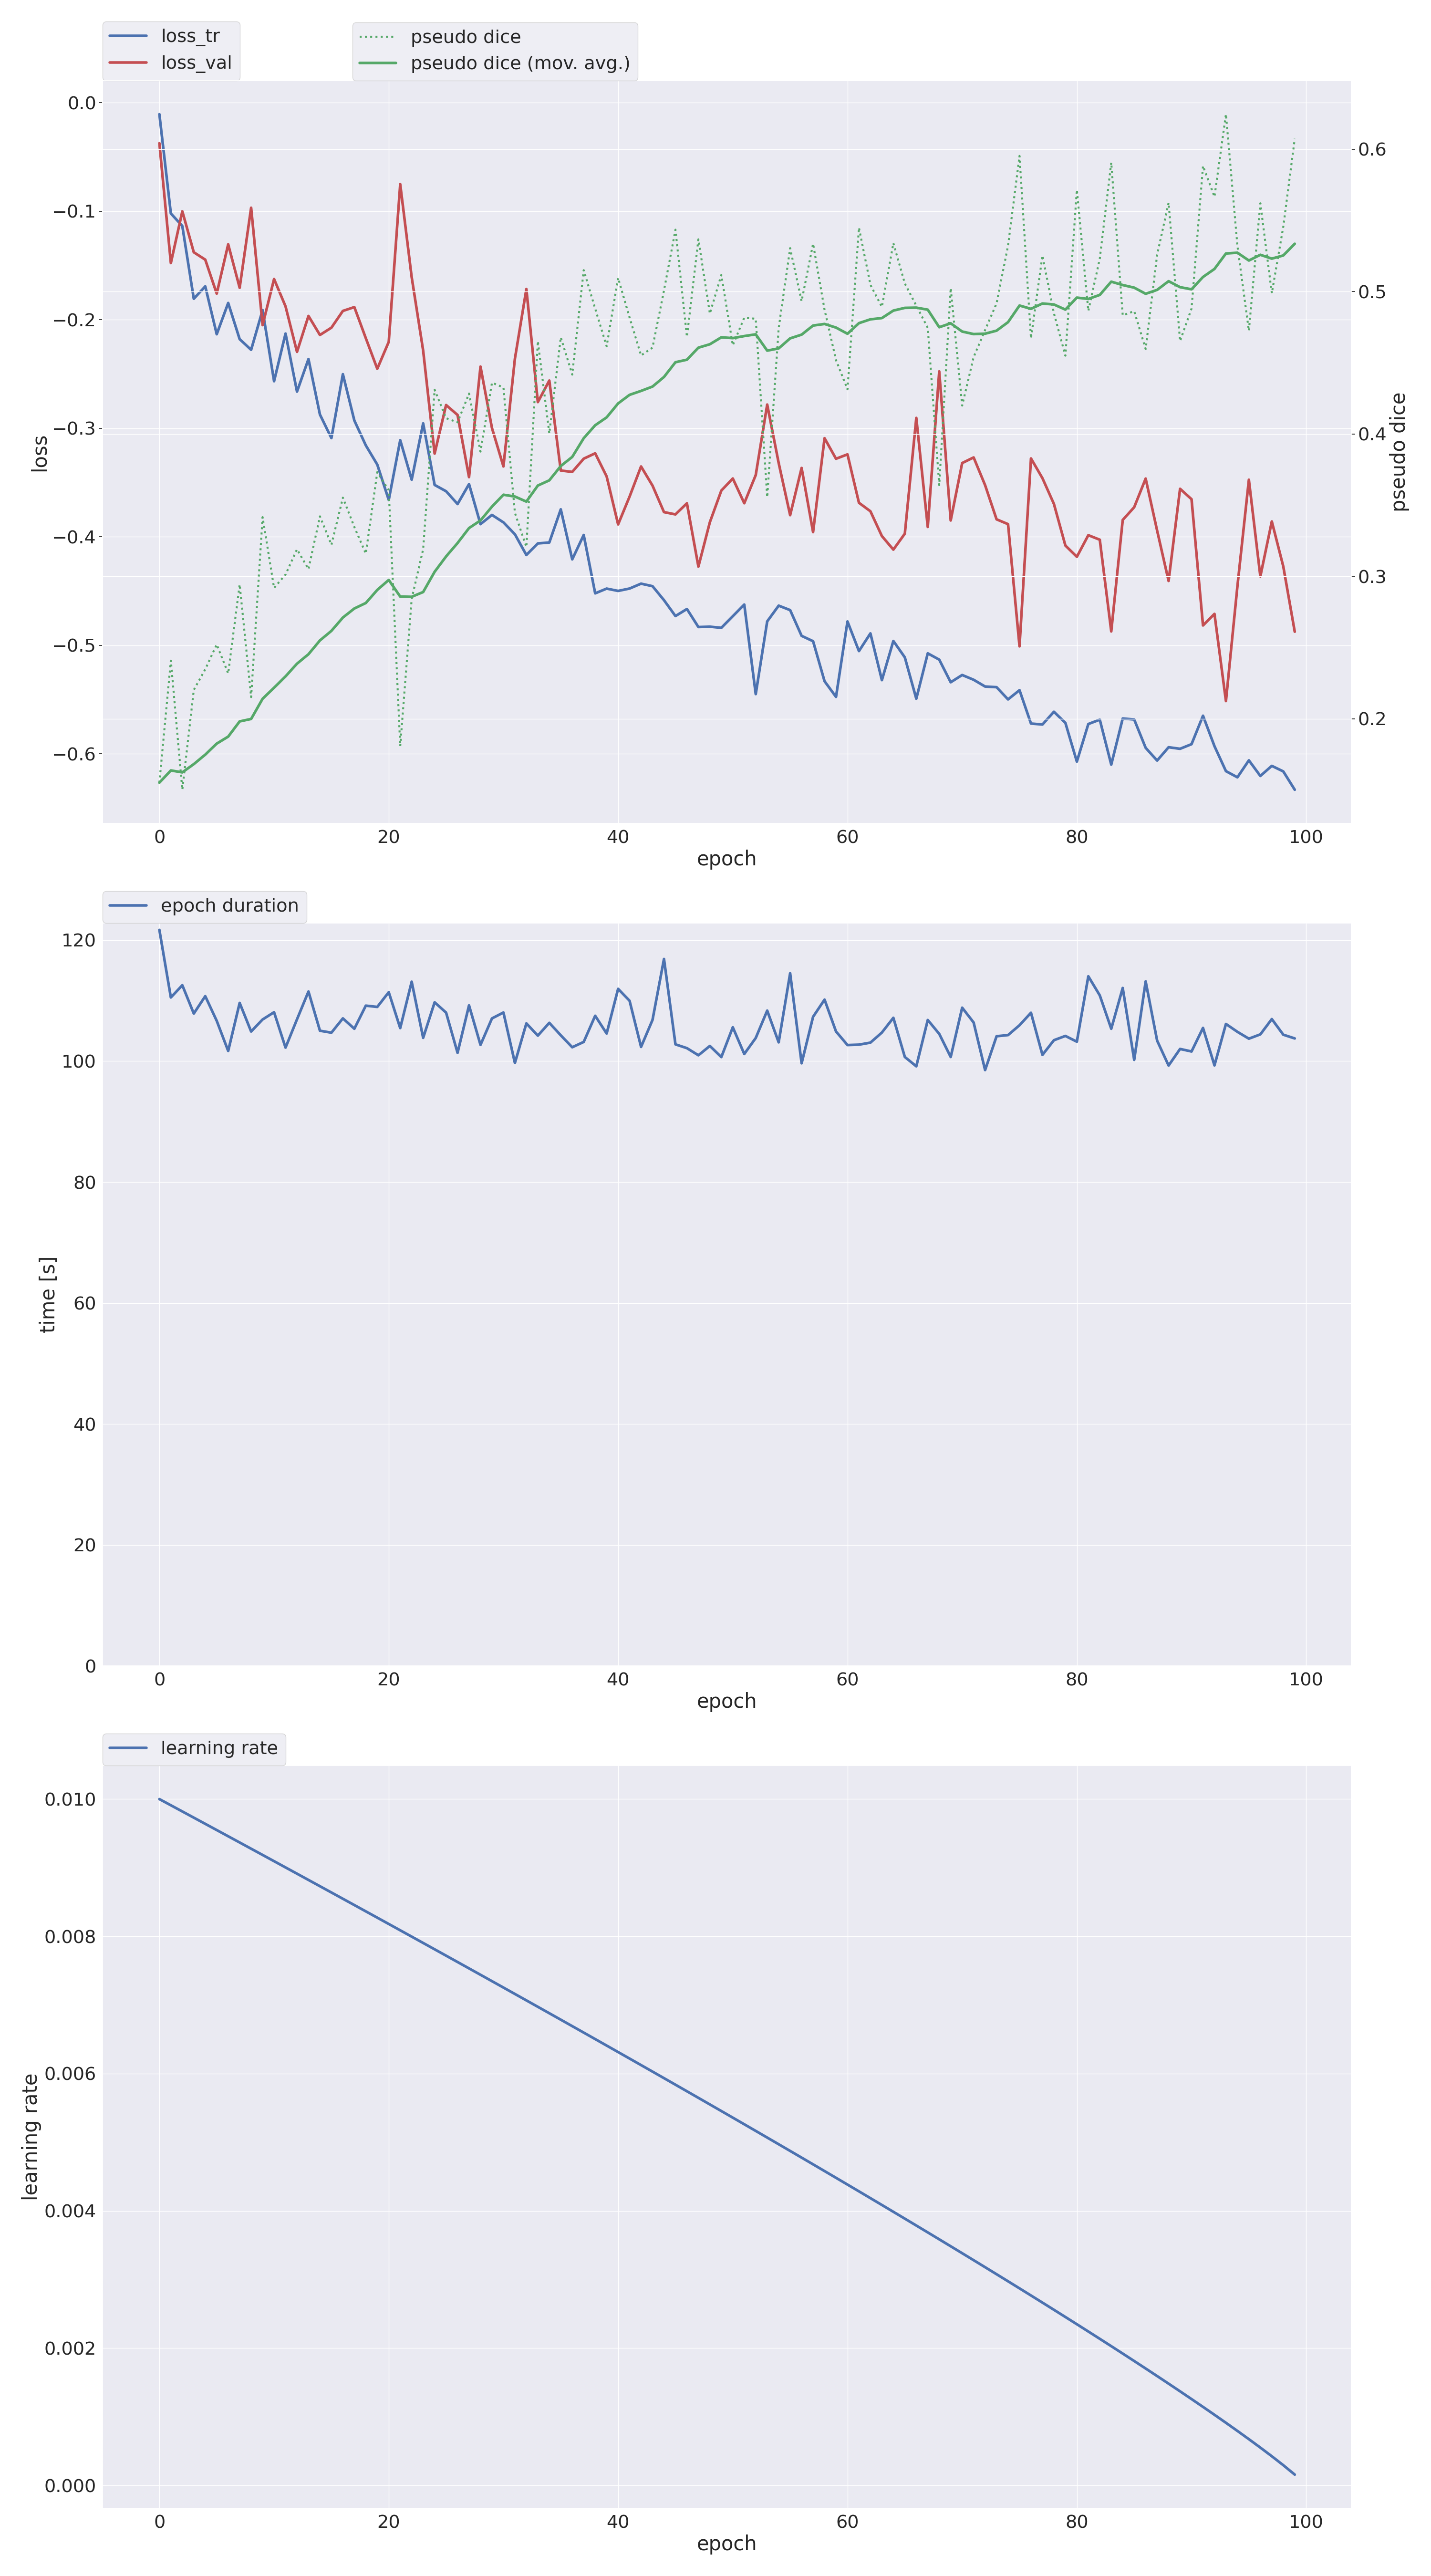

In [60]:
log_dir = "data/nnunet/nnunet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/training_log_2024_1_2_18_44_04.txt"

read_log_file(0, log_dir)

#show png file
from IPython.display import Image
PATH = "data/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/progress.png"
Image(filename = PATH)

Model with Fold number: 1
Best pseudo dice score: 0.6319
Mean dice score: 0.5229183341617413


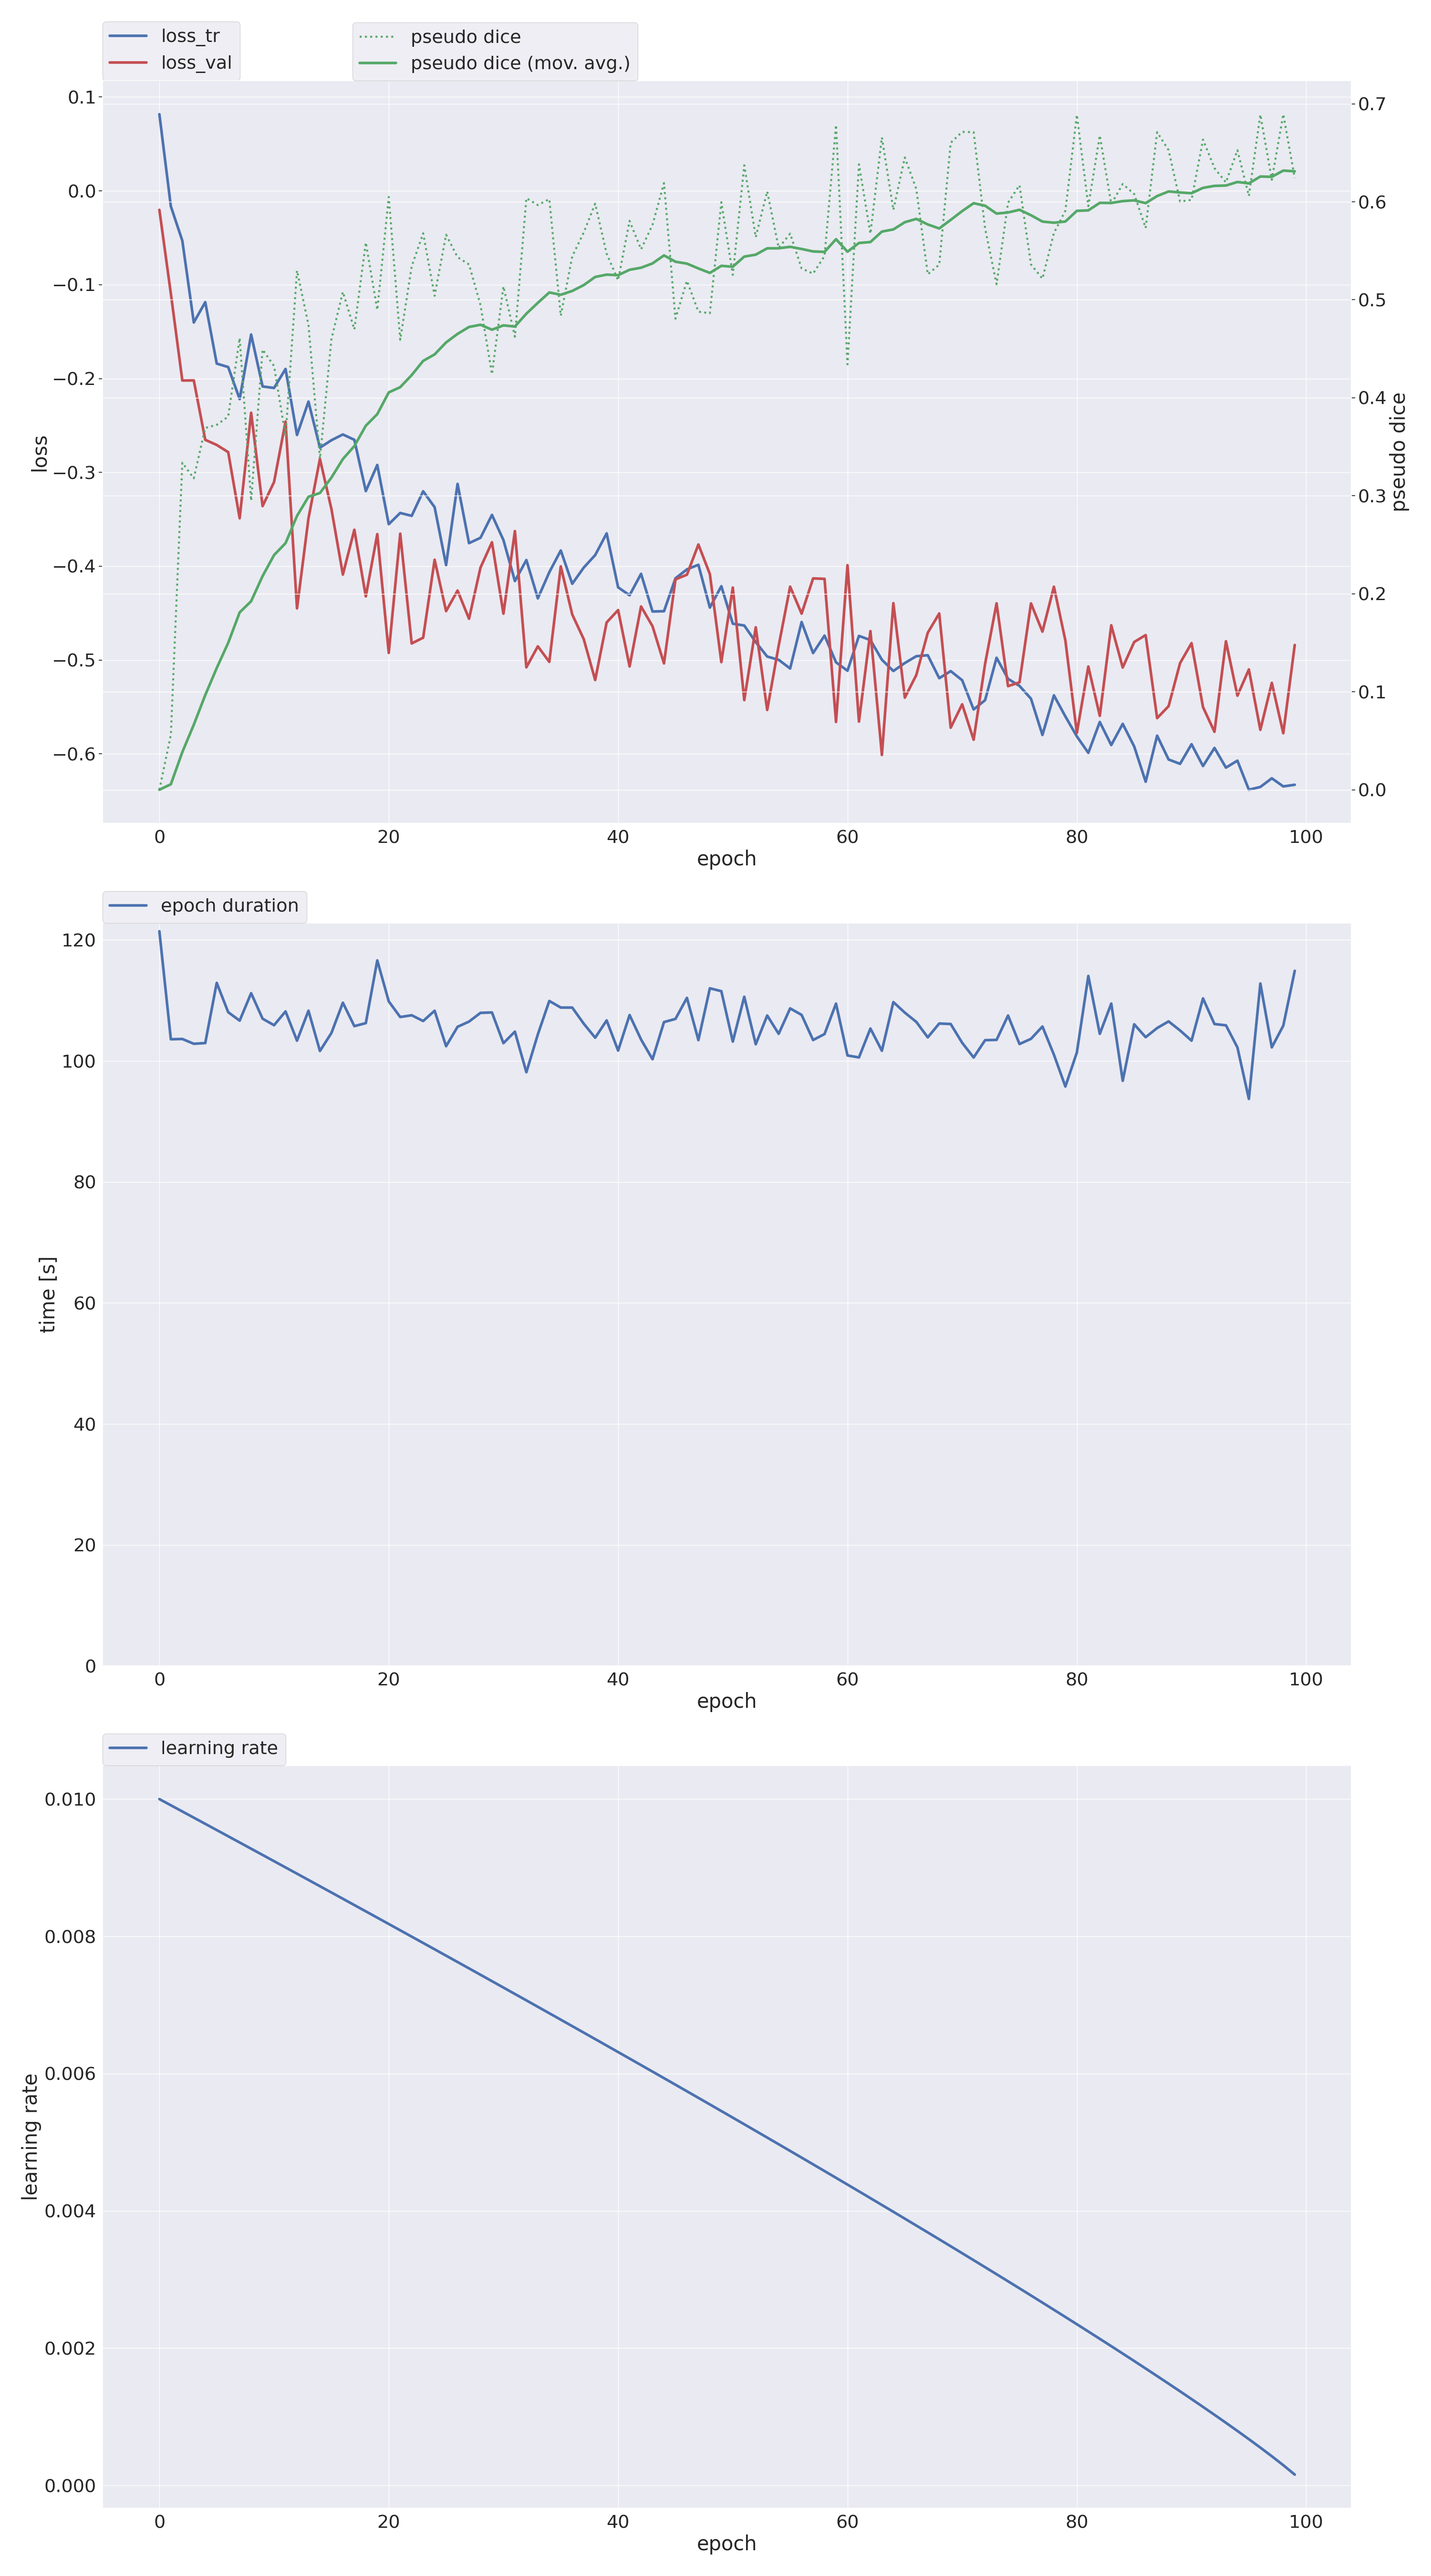

In [59]:
log_dir = "data/nnunet/nnunet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_1/training_log_2024_1_2_12_57_36.txt"

read_log_file(1, log_dir)

#show png file
from IPython.display import Image
PATH = "data/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_1/progress.png"
Image(filename = PATH)

Model with Fold number: 2
Best pseudo dice score: 0.5531
Mean dice score: 0.3887039267293557


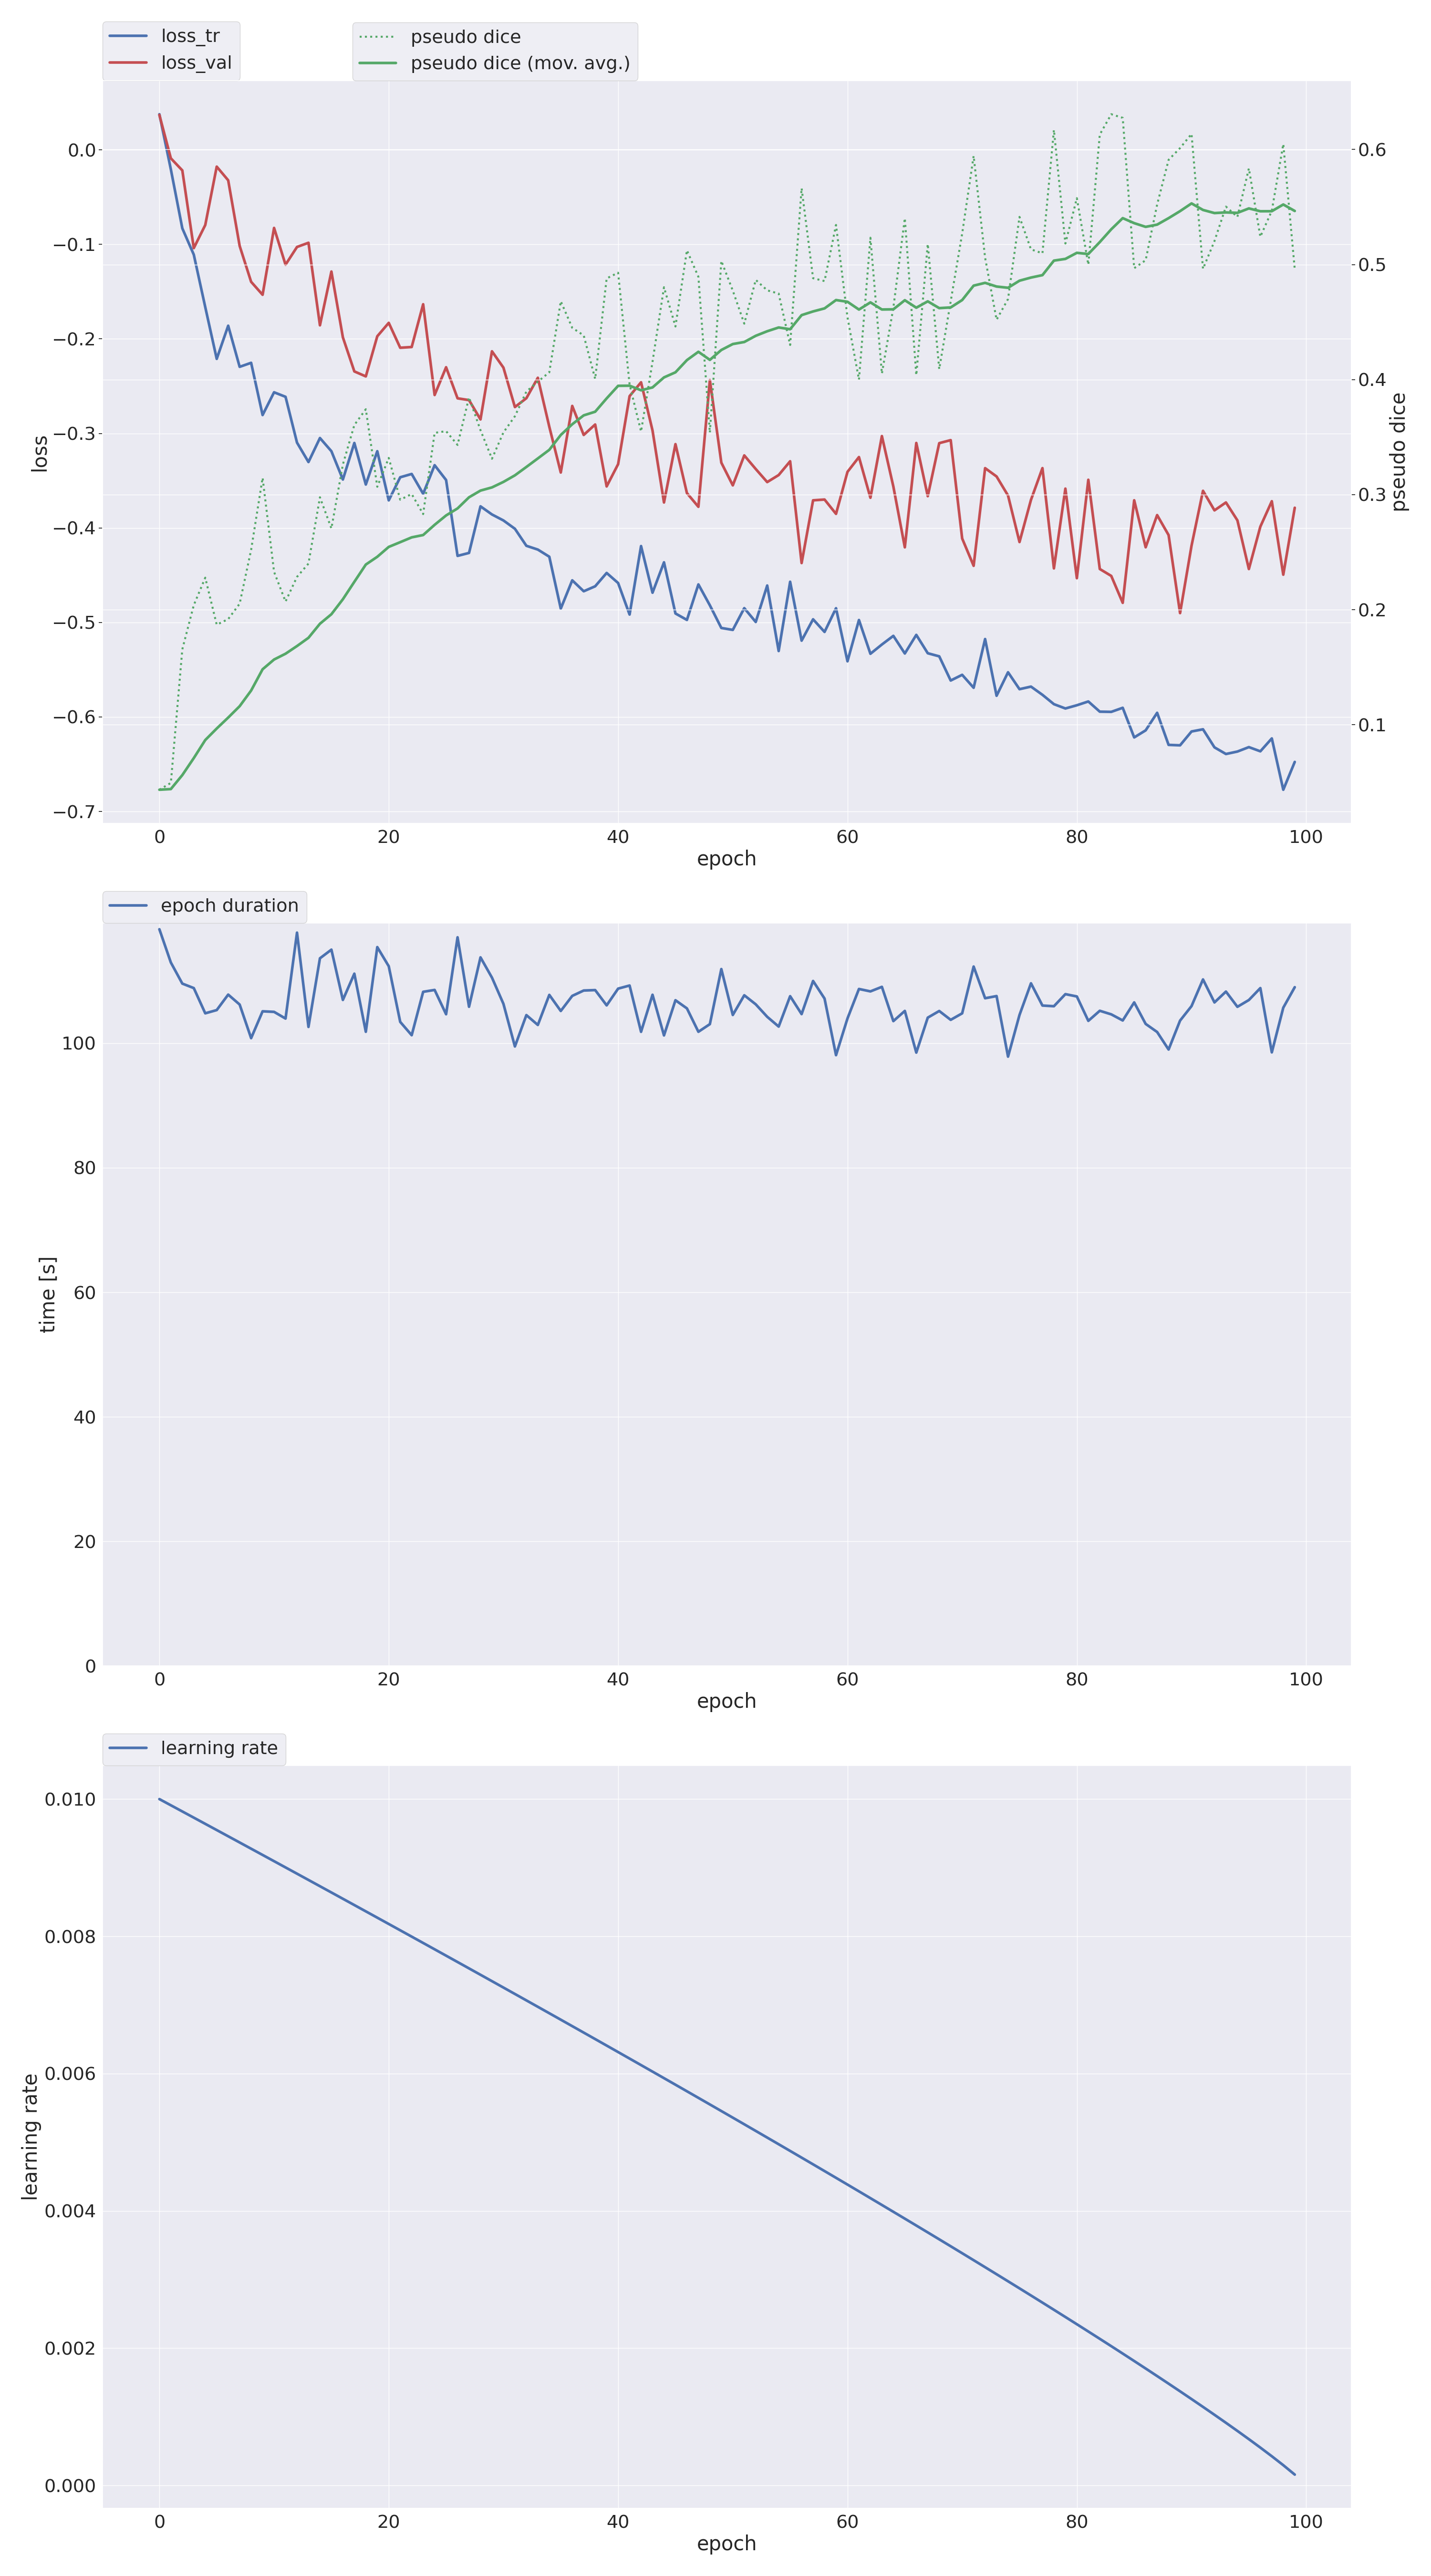

In [61]:
log_dir = "data/nnunet/nnunet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_2/training_log_2024_1_2_22_49_33.txt"

read_log_file(2, log_dir)

#show png file
from IPython.display import Image
PATH = "data/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_2/progress.png"
Image(filename = PATH)

Model with Fold number: 3
Best pseudo dice score: 0.5387
Mean dice score: 0.47935776998419327


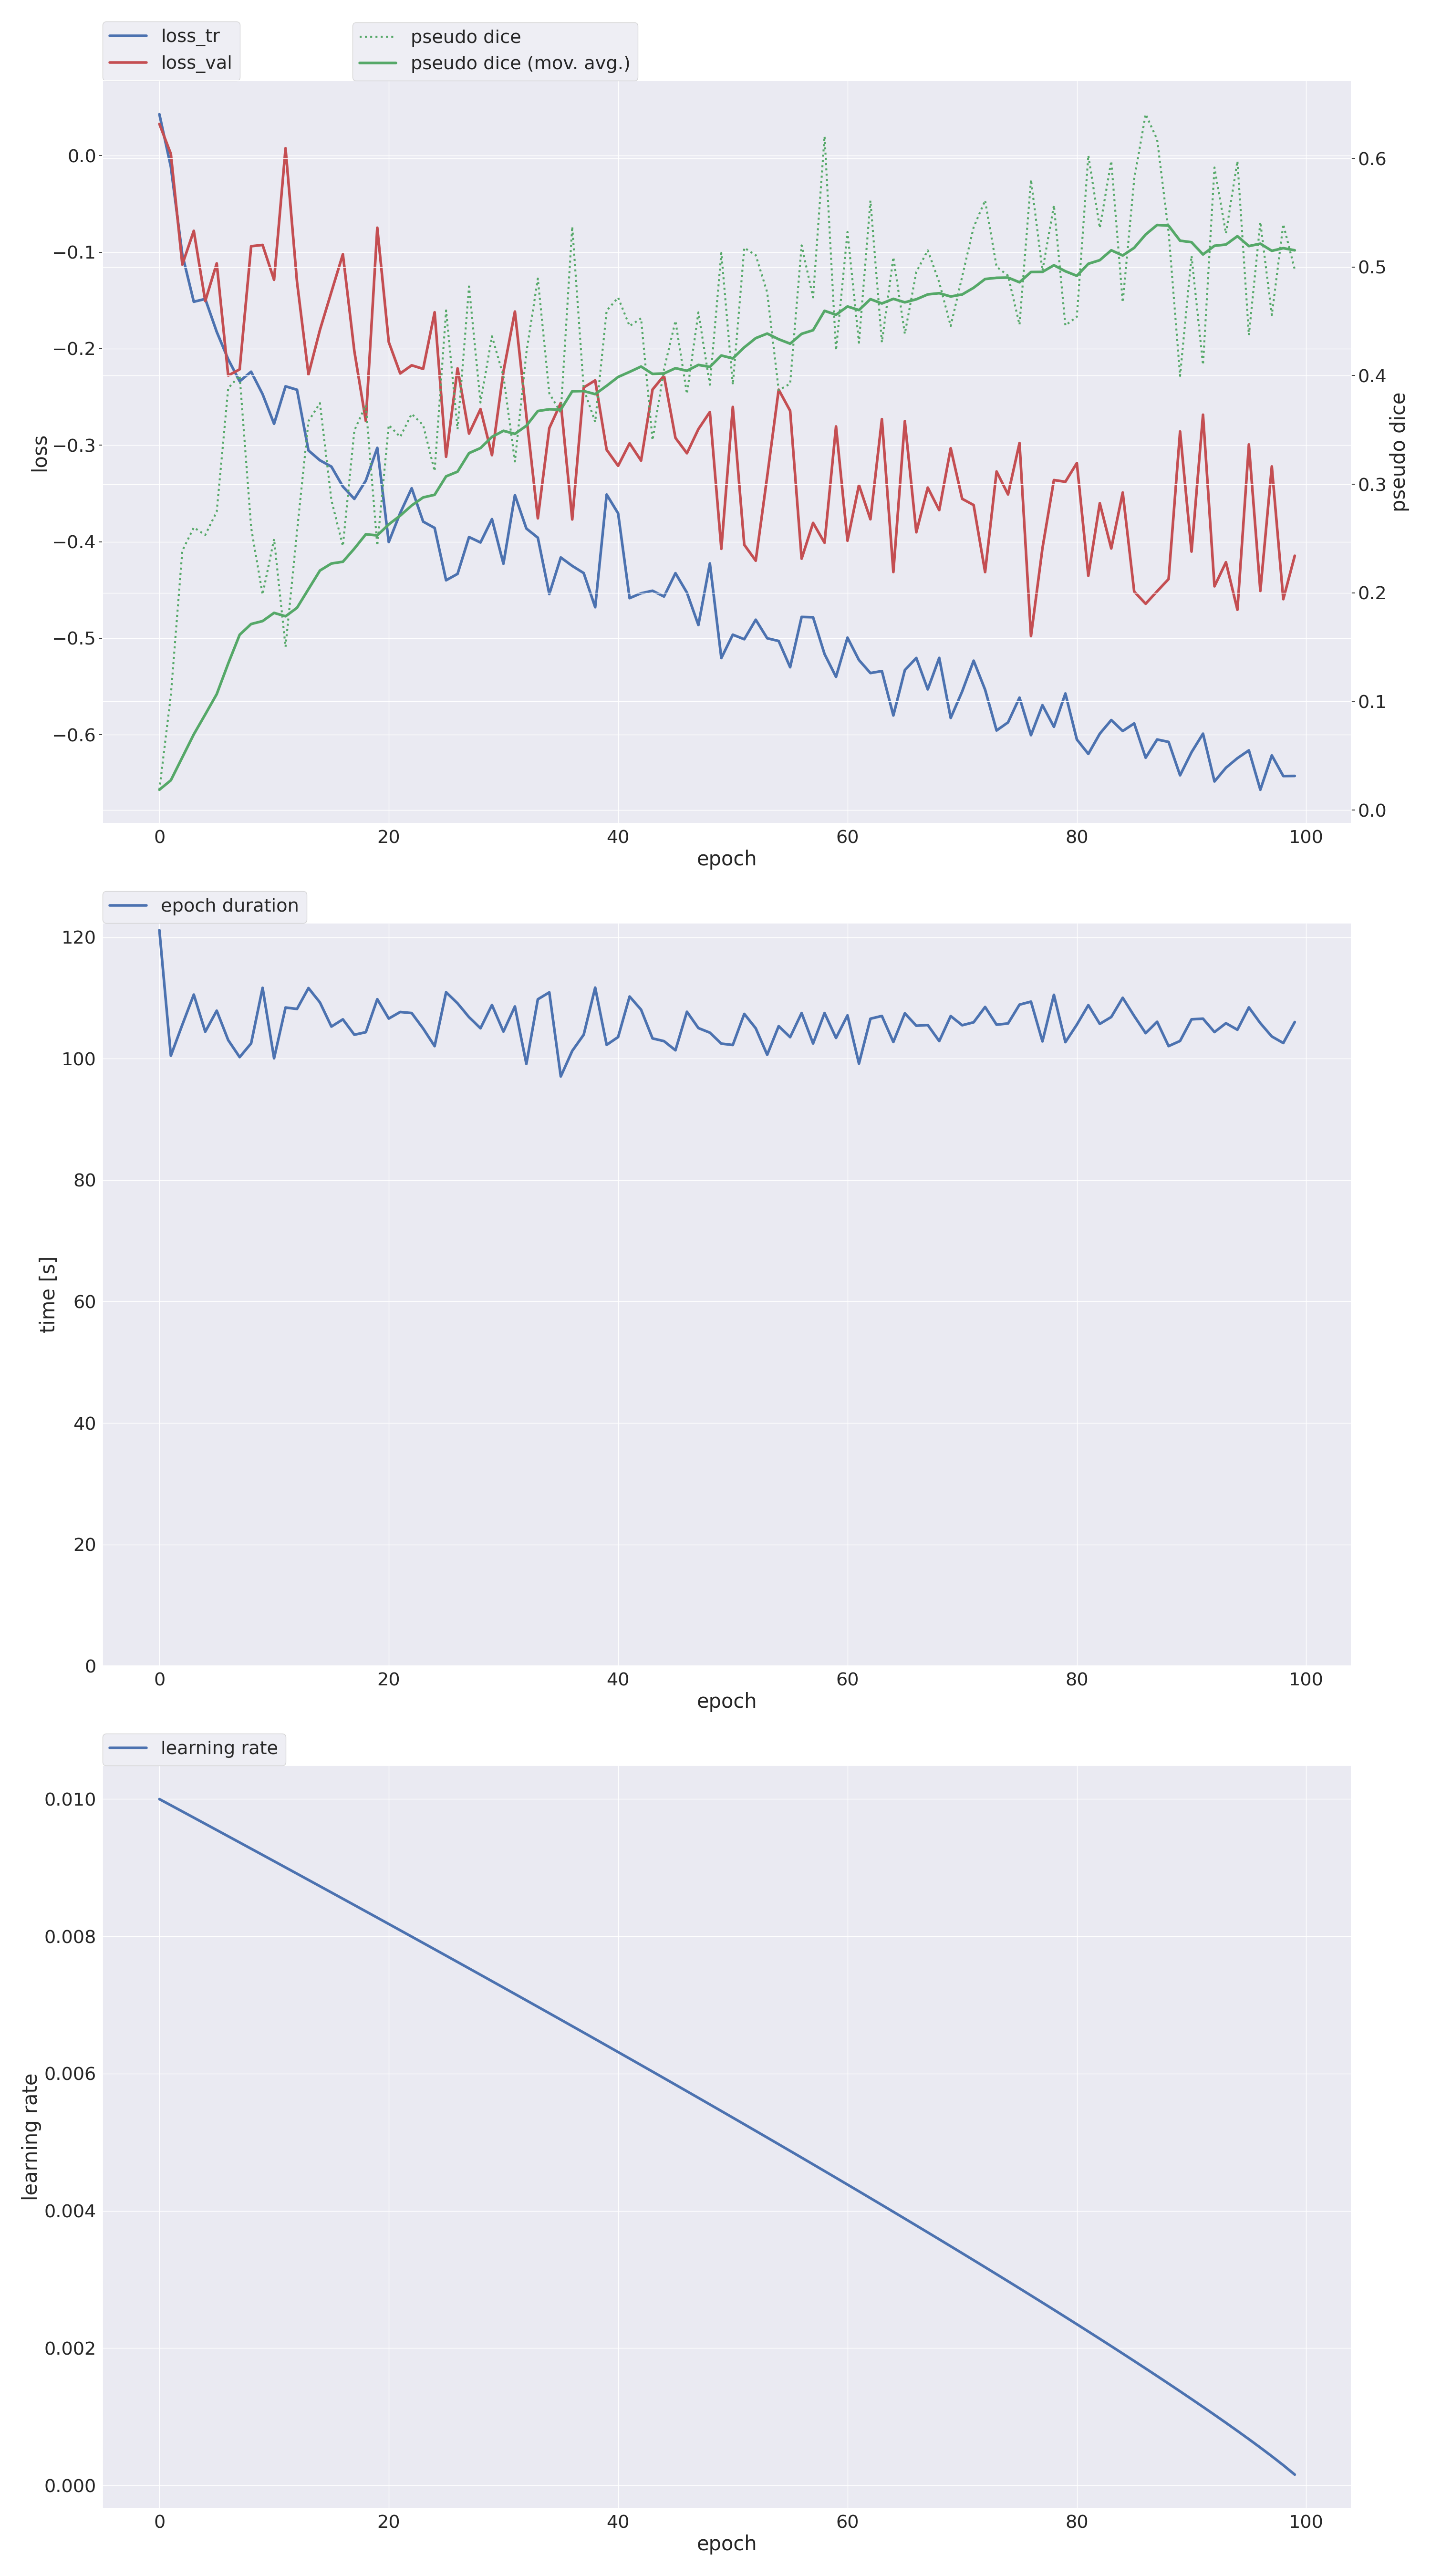

In [65]:
log_dir = "data/nnunet/nnunet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_3/training_log_2024_1_2_22_55_58.txt"

read_log_file(3, log_dir)
#show png file
from IPython.display import Image
PATH = "data/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_3/progress.png"
Image(filename = PATH)

Model with Fold number: 4
Best pseudo dice score: 0.6434
Mean dice score: 0.5671184980502029


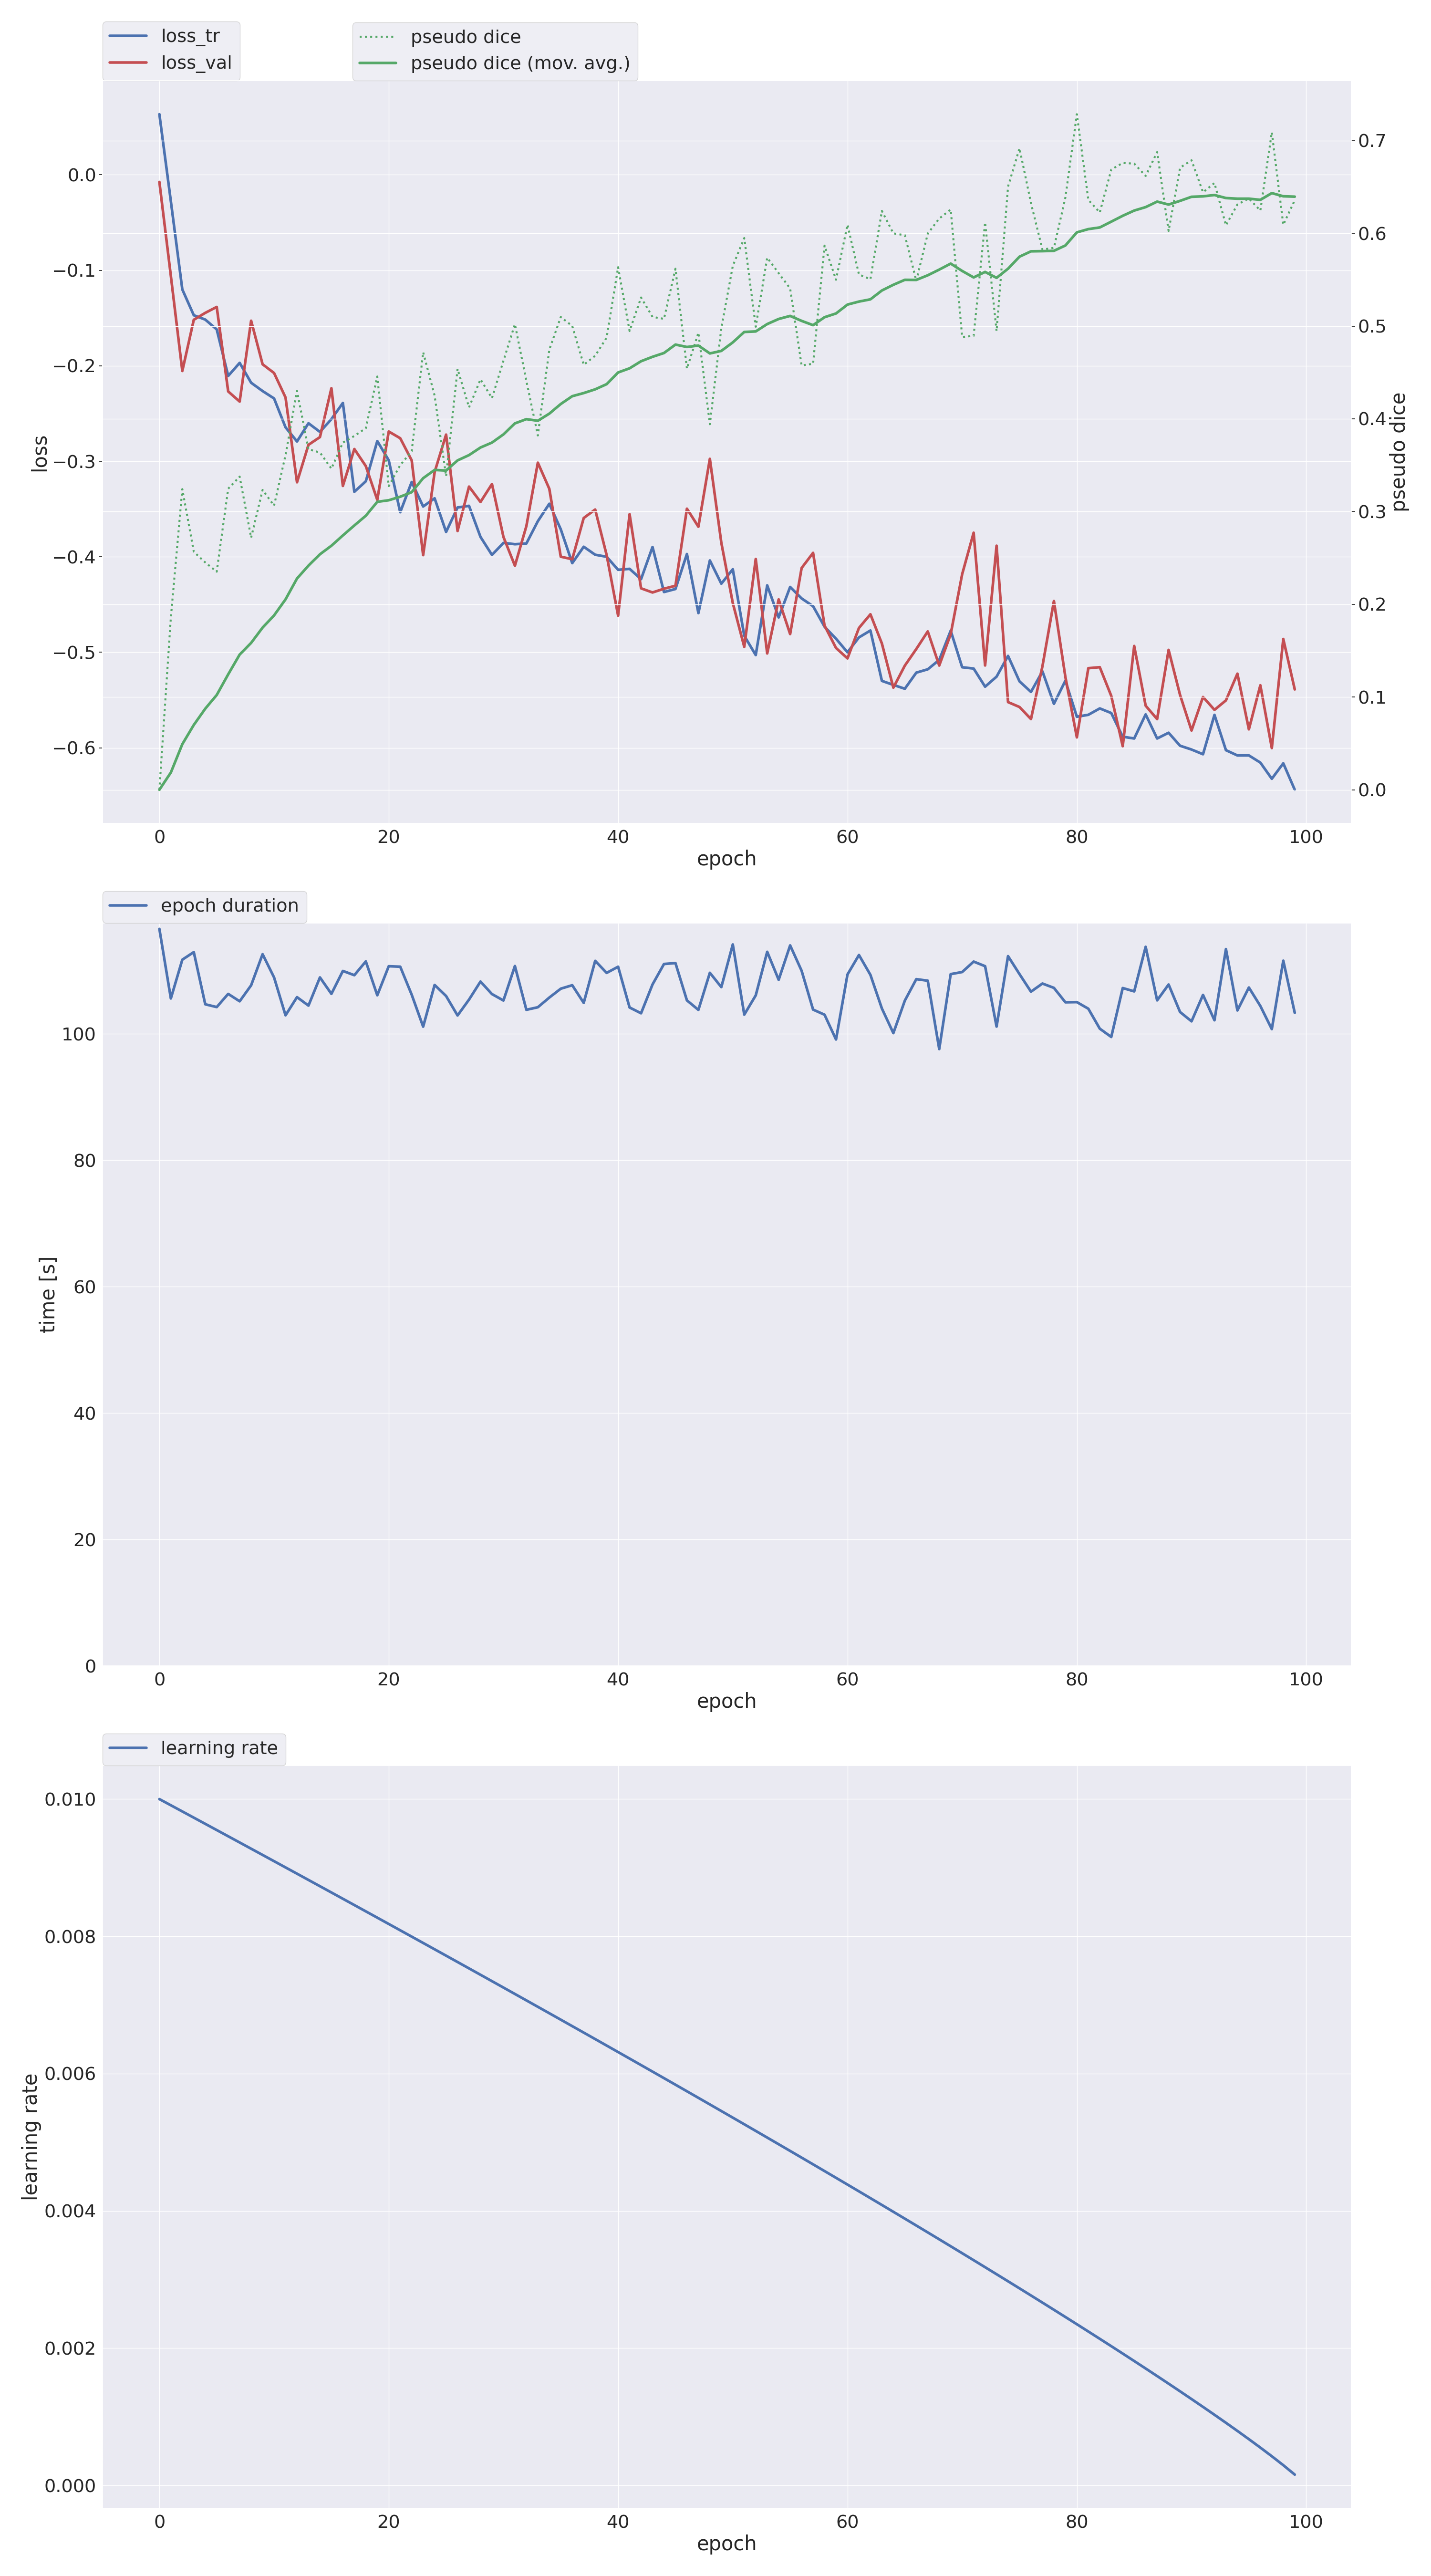

In [64]:
log_dir = "data/nnunet/nnunet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_4/training_log_2024_1_3_01_08_58.txt"

read_log_file(4, log_dir)

#show png file
from IPython.display import Image
PATH = "data/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_4/progress.png"
Image(filename = PATH)

MRI-Bild Abmessungen: (256, 256, 192)
Segmentierungsabmessungen: (256, 256, 192)


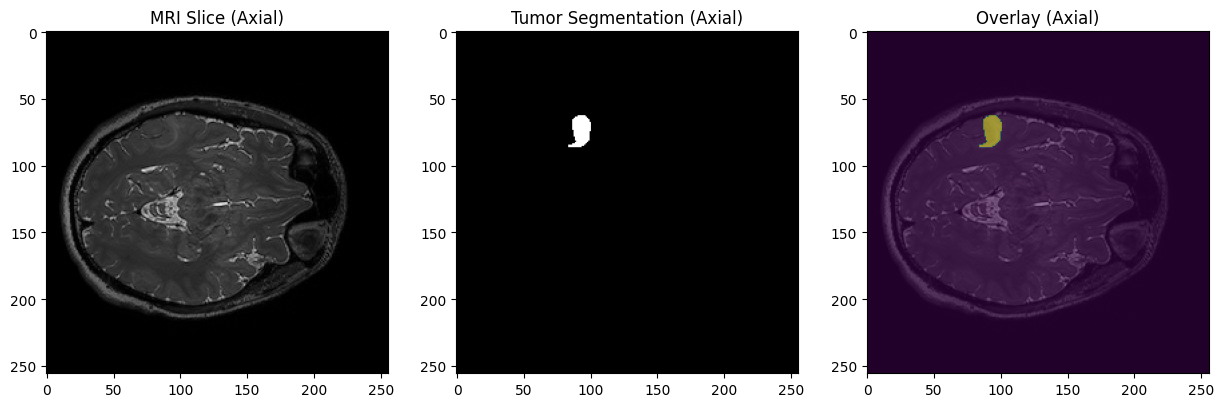

In [ ]:
# Function to load and orient NIfTI images to RAS+
def load_nifti_in_RAS(nii_img):
    canonical_img = nib.as_closest_canonical(nii_img)
    return canonical_img.get_fdata()

mri_img_nib = nib.load('data/nnunet/nnUNet_raw/Dataset001-REMIND/imagesTr/ReMIND_003_0000.nii.gz')
seg_img_nib = nib.load('/data/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4/postprocessed/ReMIND_003.nii.gz')

mri_image_nib = mri_img_nib.get_fdata()

seg_image_nib = seg_img_nib.get_fdata()

print("MRI-Bild Abmessungen:", mri_image_nib.shape)
print("Segmentierungsabmessungen:", seg_image_nib.shape)

mri_data = load_nifti_in_RAS(mri_img_nib)
segmentation_data = load_nifti_in_RAS(seg_img_nib)

# Assuming both are now aligned and oriented similarly, get a slice
middle_slice_index = mri_data.shape[2] // 2  # adjust as necessary

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['MRI Slice (Axial)', 'Tumor Segmentation (Axial)', 'Overlay (Axial)']

# Plot MRI Slice (Axial)
axes[0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0].set_title(titles[0])

# Plot Tumor Segmentation (Axial)
axes[1].imshow(segmentation_data[:, :, middle_slice_index], cmap='gray')
axes[1].set_title(titles[1])

# Plot Overlay (Axial)
axes[2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[2].imshow(segmentation_data[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[2].set_title(titles[2])

# Display the plots
plt.show()


Check one validation from fold 0 where Dice Score is 0. 

MRI-Bild Abmessungen: (192, 256, 256)
Segmentierungsabmessungen Original: (192, 256, 256)
Segmentierungsabmessungen Predicted: (192, 256, 256)


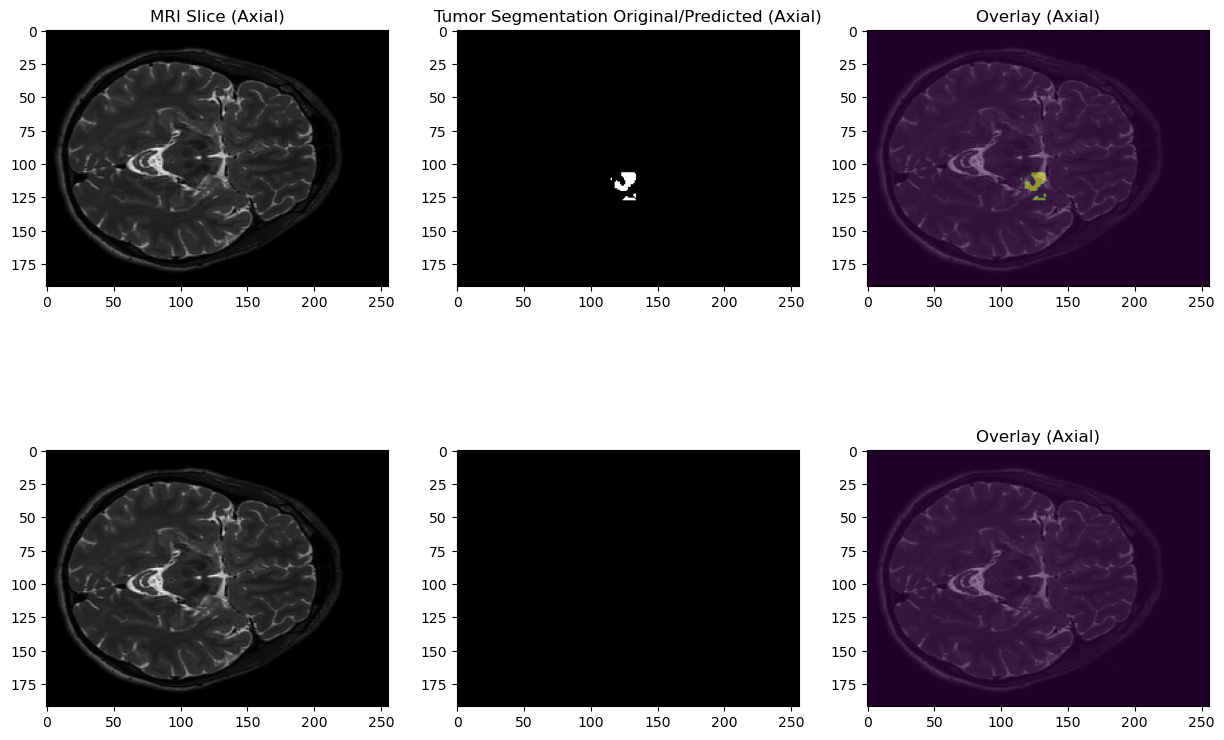

In [89]:
# Function to load and orient NIfTI images to RAS+
def load_nifti_in_RAS(nii_img):
    canonical_img = nib.as_closest_canonical(nii_img)
    return canonical_img.get_fdata()

mri_img_nib = nib.load('data/nnunet/nnUNet_raw/Dataset001-REMIND/imagesTr/ReMIND_005_0000.nii.gz')
seg_img_nib = nib.load('data/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/ReMIND_005.nii.gz')
seg_img_nib_orig = nib.load(os.path.join('data/nnunet/nnunet_raw/Dataset001-REMIND/labelsTr', 'ReMIND_005.nii.gz'))


mri_image_nib = mri_img_nib.get_fdata()
seg_image_nib = seg_img_nib.get_fdata()
seg_image_nib_orig = seg_img_nib_orig.get_fdata()

print("MRI-Bild Abmessungen:", mri_image_nib.shape)
print("Segmentierungsabmessungen Original:", seg_image_nib.shape)
print("Segmentierungsabmessungen Predicted:", seg_img_nib_orig.shape)

mri_data = load_nifti_in_RAS(mri_img_nib)
segmentation_data = load_nifti_in_RAS(seg_img_nib)
segmentation_data_orig = load_nifti_in_RAS(seg_img_nib_orig)

# Assuming both are now aligned and oriented similarly, get a slice
middle_slice_index = 150 # adjust as necessary

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
titles = ['MRI Slice (Axial)', 'Tumor Segmentation Original/Predicted (Axial)', 'Overlay (Axial)']

# Plot MRI Slice (Axial)
axes[0][0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0][0].set_title(titles[0])

# Plot Tumor Segmentation (Axial)
axes[0][1].imshow(segmentation_data_orig[:, :, middle_slice_index], cmap='gray')
axes[0][1].set_title(titles[1])

# Plot Overlay (Axial)
axes[0][2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0][2].imshow(segmentation_data_orig[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[0][2].set_title(titles[2])

# Plot MRI Slice (Axial)
axes[1][0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0][0].set_title(titles[0])

# Plot Tumor Segmentation (Axial)
axes[1][1].imshow(segmentation_data[:, :, middle_slice_index], cmap='gray')
axes[0][1].set_title(titles[1])

# Plot Overlay (Axial)
axes[1][2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[1][2].imshow(segmentation_data[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[1][2].set_title(titles[2])

# Display the plots
plt.show()


MRI-Bild Abmessungen: (256, 256, 192)
Segmentierungsabmessungen Original: (256, 256, 192)
Segmentierungsabmessungen Predicted: (256, 256, 192)


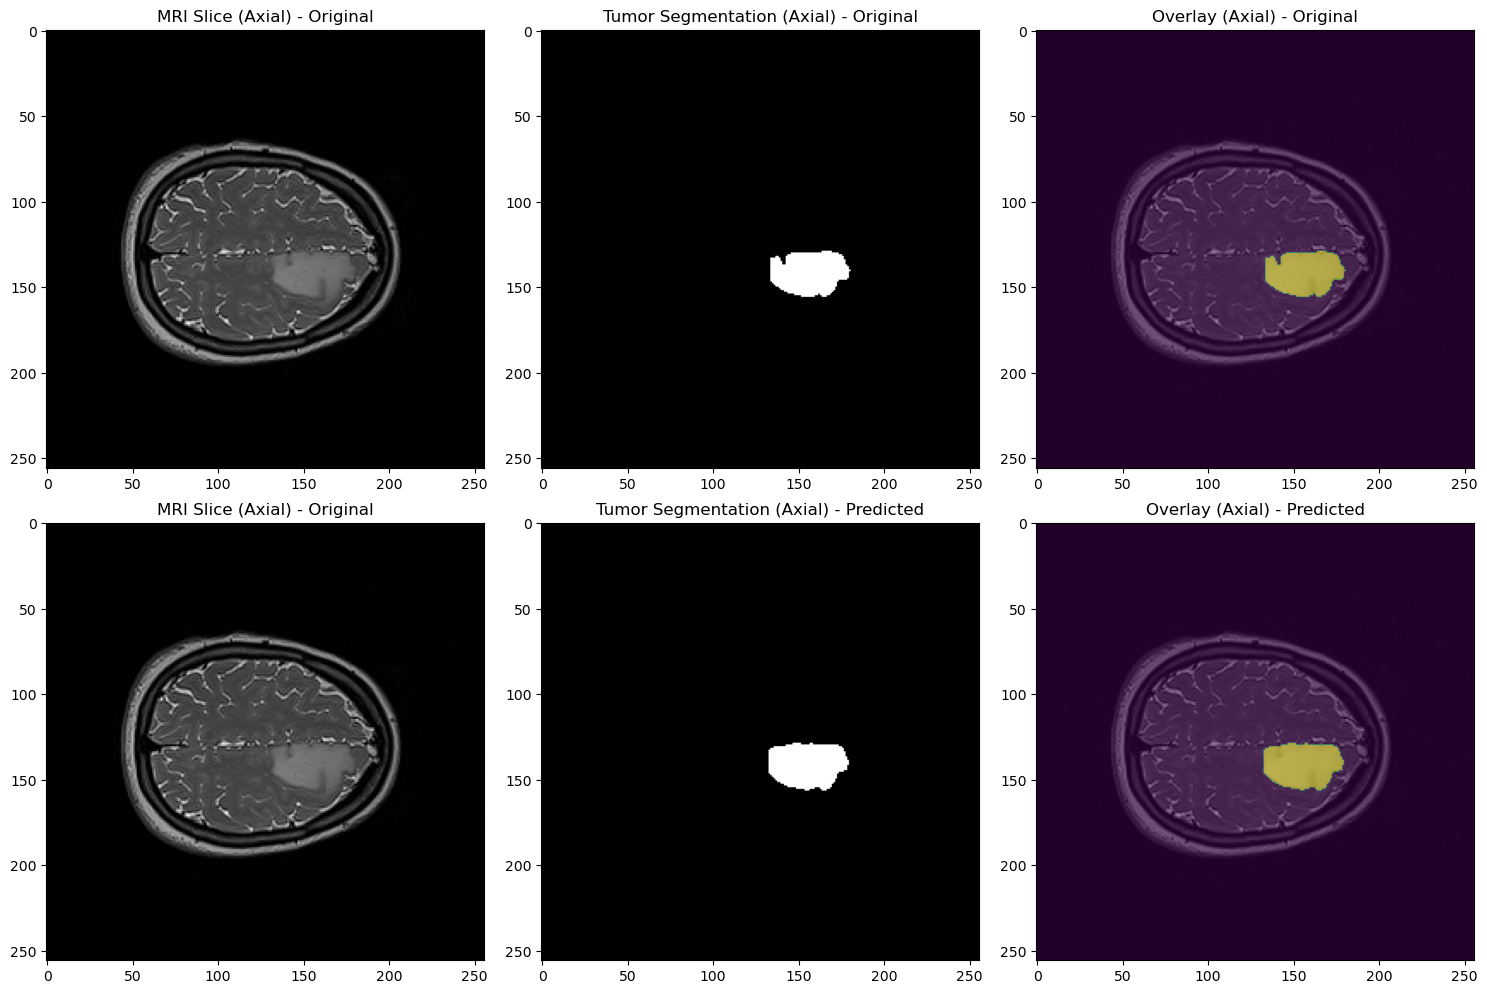

In [112]:
# Function to load and orient NIfTI images to RAS+
def load_nifti_in_RAS(nii_img):
    canonical_img = nib.as_closest_canonical(nii_img)
    return canonical_img.get_fdata()

mri_img_nib = nib.load('data/nnunet/nnUNet_raw/Dataset001-REMIND/imagesTr/ReMIND_002_0000.nii.gz')
seg_img_nib = nib.load('data/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_4/validation/ReMIND_002.nii.gz')
seg_img_nib_orig = nib.load(os.path.join('data/nnunet/nnunet_raw/Dataset001-REMIND/labelsTr', 'ReMIND_002.nii.gz'))


mri_image_nib = mri_img_nib.get_fdata()
seg_image_nib = seg_img_nib.get_fdata()
seg_image_nib_orig = seg_img_nib_orig.get_fdata()

print("MRI-Bild Abmessungen:", mri_image_nib.shape)
print("Segmentierungsabmessungen Original:", seg_image_nib.shape)
print("Segmentierungsabmessungen Predicted:", seg_img_nib_orig.shape)

mri_data = load_nifti_in_RAS(mri_img_nib)
segmentation_data = load_nifti_in_RAS(seg_img_nib)
segmentation_data_orig = load_nifti_in_RAS(seg_img_nib_orig)

# Assuming both are now aligned and oriented similarly, get a slice
middle_slice_index = 150 # adjust as necessary

# Create subplots
# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
titles = [
    'MRI Slice (Axial) - Original',
    'Tumor Segmentation (Axial) - Original',
    'Overlay (Axial) - Original',
    'MRI Slice (Axial) - Original',
    'Tumor Segmentation (Axial) - Predicted',
    'Overlay (Axial) - Predicted'
]

# Plot for the first row (Original)
axes[0][0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0][0].set_title(titles[0])

axes[0][1].imshow(segmentation_data_orig[:, :, middle_slice_index], cmap='gray')
axes[0][1].set_title(titles[1])

axes[0][2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0][2].imshow(segmentation_data_orig[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[0][2].set_title(titles[2])

# Plot for the second row (Predicted)
axes[1][0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[1][0].set_title(titles[3])

axes[1][1].imshow(segmentation_data[:, :, middle_slice_index], cmap='gray')
axes[1][1].set_title(titles[4])

axes[1][2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[1][2].imshow(segmentation_data[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[1][2].set_title(titles[5])

# Adjust layout and display
plt.tight_layout()
plt.show()

MRI-Bild Abmessungen: (232, 256, 192)
Segmentierungsabmessungen Original: (232, 256, 192)
Segmentierungsabmessungen Predicted: (232, 256, 192)


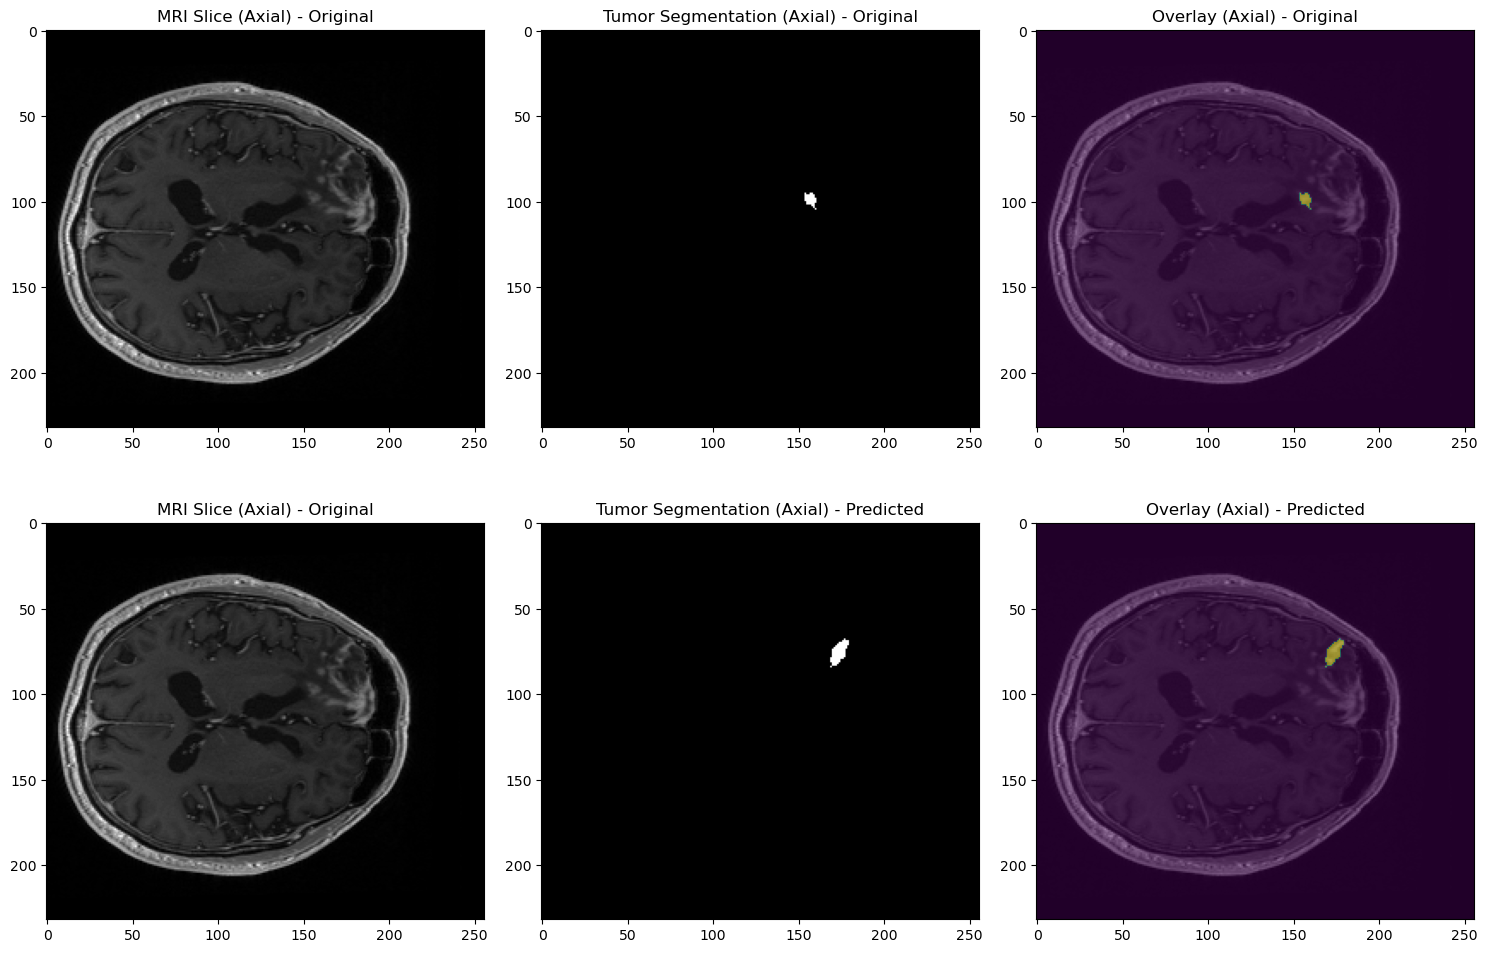

In [111]:
# Function to load and orient NIfTI images to RAS+
def load_nifti_in_RAS(nii_img):
    canonical_img = nib.as_closest_canonical(nii_img)
    return canonical_img.get_fdata()

mri_img_nib = nib.load('data/nnunet/nnUNet_raw/Dataset001-REMIND/imagesTr/ReMIND_075_0000.nii.gz')
seg_img_nib = nib.load('data/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_4/validation/ReMIND_075.nii.gz')
seg_img_nib_orig = nib.load(os.path.join('data/nnunet/nnunet_raw/Dataset001-REMIND/labelsTr', 'ReMIND_075.nii.gz'))


mri_image_nib = mri_img_nib.get_fdata()
seg_image_nib = seg_img_nib.get_fdata()
seg_image_nib_orig = seg_img_nib_orig.get_fdata()

print("MRI-Bild Abmessungen:", mri_image_nib.shape)
print("Segmentierungsabmessungen Original:", seg_image_nib.shape)
print("Segmentierungsabmessungen Predicted:", seg_img_nib_orig.shape)

mri_data = load_nifti_in_RAS(mri_img_nib)
segmentation_data = load_nifti_in_RAS(seg_img_nib)
segmentation_data_orig = load_nifti_in_RAS(seg_img_nib_orig)

# Assuming both are now aligned and oriented similarly, get a slice
middle_slice_index = 95 # adjust as necessary

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
titles = [
    'MRI Slice (Axial) - Original',
    'Tumor Segmentation (Axial) - Original',
    'Overlay (Axial) - Original',
    'MRI Slice (Axial) - Original',
    'Tumor Segmentation (Axial) - Predicted',
    'Overlay (Axial) - Predicted'
]

# Plot for the first row (Original)
axes[0][0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0][0].set_title(titles[0])

axes[0][1].imshow(segmentation_data_orig[:, :, middle_slice_index], cmap='gray')
axes[0][1].set_title(titles[1])

axes[0][2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0][2].imshow(segmentation_data_orig[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[0][2].set_title(titles[2])

# Plot for the second row (Predicted)
axes[1][0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[1][0].set_title(titles[3])

axes[1][1].imshow(segmentation_data[:, :, middle_slice_index], cmap='gray')
axes[1][1].set_title(titles[4])

axes[1][2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[1][2].imshow(segmentation_data[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[1][2].set_title(titles[5])

# Adjust layout and display
plt.tight_layout()
plt.show()


In [ ]:
!nnUNetv2_predict -d Dataset001-REMIND -i /content/drive/MyDrive/nnunet/nnUNet_raw/Dataset001-REMIND/imagesTs -o /content/drive/MyDrive/nnunet/nnUNet_results/Dataset001-REMIND/inference -f  0 1 2 3 4 -tr nnUNetTrainer -c 3d_fullres -p nnUNetPlans


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 14 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 14 cases that I would like to predict

Predicting ReMIND_002:
perform_everything_on_gpu: True
100% 18/18 [00:16<00:00,  1.11it/s]
100% 18/18 [00:15<00:00,  1.16it/s]
100% 18/18 [00:15<00:00,  1.14it/s]
100% 18/18 [00:15<00:00,  1.13it/s]
100% 18/18 [00:16<00:00,  1.11it/s]
Prediction done, transferring to CPU if needed
sending off prediction to background worker for resampling and export
done with ReMIND_002

Predicting ReMIND_004:
perform_everything_on_gpu: True
100% 2

In [ ]:
# The following is an operating system command, remember to prefix with !
!nnUNetv2_apply_postprocessing -i /content/drive/MyDrive/nnunet/nnUNet_results/Dataset001-REMIND/inference -o /content/drive/MyDrive/nnunet/nnUNet_results/Dataset001-REMIND/postprocessing -pp_pkl_file /content/drive/MyDrive/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4/postprocessing.pkl -np 8 -plans_json /content/drive/MyDrive/nnunet/nnUNet_results/Dataset001-REMIND/nnUNetTrainer__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4/plans.json

MRI-Bild Abmessungen: (256, 256, 176)
Segmentierungsabmessungen Original: (256, 256, 176)
Segmentierungsabmessungen Predicted: (256, 256, 176)


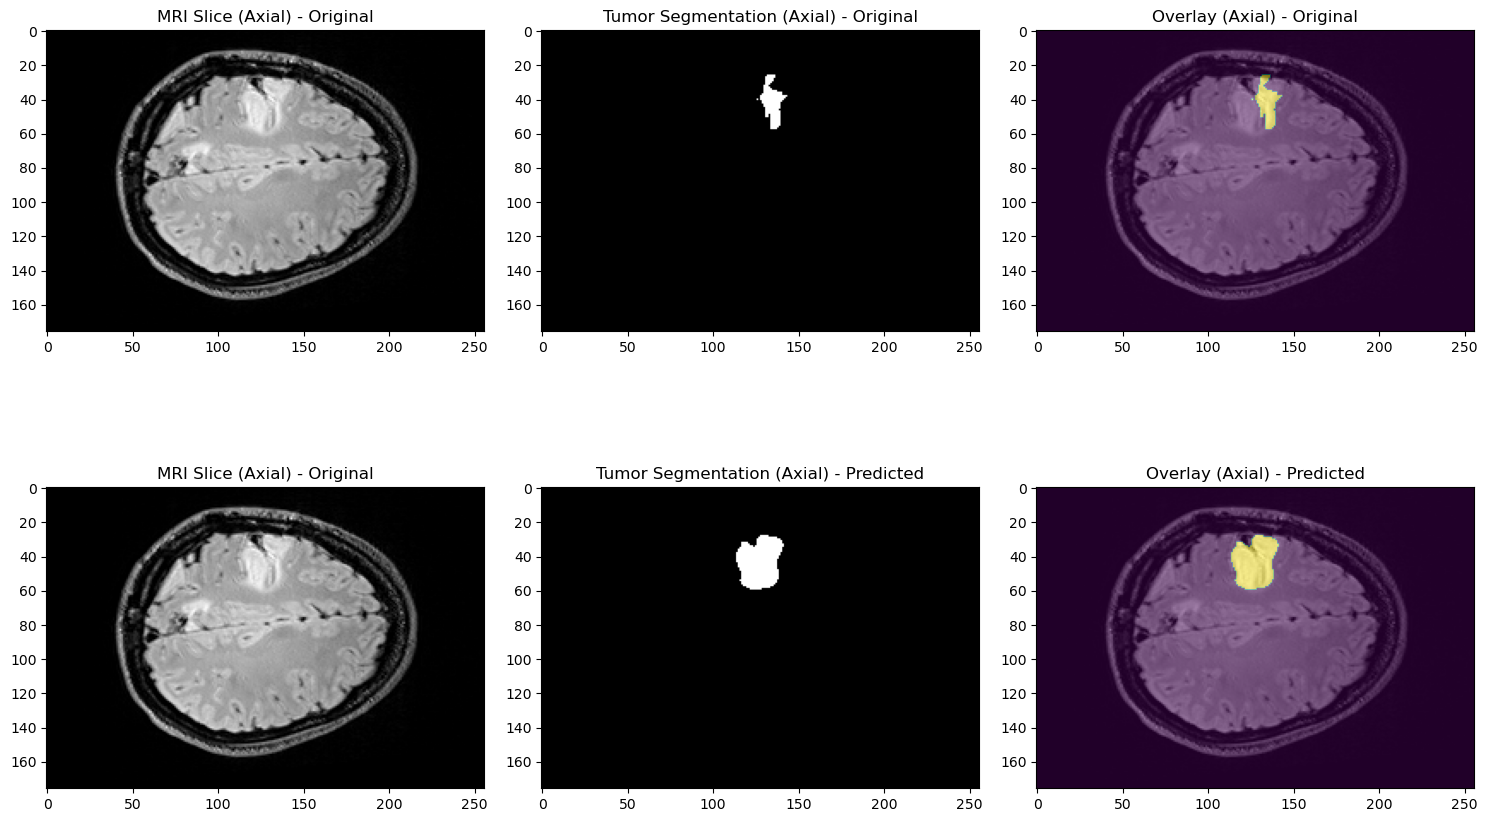

In [132]:
# Function to load and orient NIfTI images to RAS+
def load_nifti_in_RAS(nii_img):
    canonical_img = nib.as_closest_canonical(nii_img)
    return canonical_img.get_fdata()

mri_img_nib = nib.load('data/nnunet/nnUNet_raw/Dataset001-REMIND/imagesTs/ReMIND_012_0000.nii.gz')
seg_img_nib = nib.load('data/nnunet/nnUNet_results/Dataset001-REMIND/postprocessing/ReMIND_012.nii.gz')
seg_img_nib_orig = nib.load(os.path.join('data/nnunet/nnunet_raw/Dataset001-REMIND/labelsTs', 'ReMIND_012.nii'))


mri_image_nib = mri_img_nib.get_fdata()
seg_image_nib = seg_img_nib.get_fdata()
seg_image_nib_orig = seg_img_nib_orig.get_fdata()

print("MRI-Bild Abmessungen:", mri_image_nib.shape)
print("Segmentierungsabmessungen Original:", seg_image_nib.shape)
print("Segmentierungsabmessungen Predicted:", seg_img_nib_orig.shape)

mri_data = load_nifti_in_RAS(mri_img_nib)
segmentation_data = load_nifti_in_RAS(seg_img_nib)
segmentation_data_orig = load_nifti_in_RAS(seg_img_nib_orig)

# Assuming both are now aligned and oriented similarly, get a slice
middle_slice_index = 184 # adjust as necessary

# Create subplots
# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
titles = [
    'MRI Slice (Axial) - Original',
    'Tumor Segmentation (Axial) - Original',
    'Overlay (Axial) - Original',
    'MRI Slice (Axial) - Original',
    'Tumor Segmentation (Axial) - Predicted',
    'Overlay (Axial) - Predicted'
]

# Plot for the first row (Original)
axes[0][0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0][0].set_title(titles[0])

axes[0][1].imshow(segmentation_data_orig[:, :, middle_slice_index], cmap='gray')
axes[0][1].set_title(titles[1])

axes[0][2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[0][2].imshow(segmentation_data_orig[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[0][2].set_title(titles[2])

# Plot for the second row (Predicted)
axes[1][0].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[1][0].set_title(titles[3])

axes[1][1].imshow(segmentation_data[:, :, middle_slice_index], cmap='gray')
axes[1][1].set_title(titles[4])

axes[1][2].imshow(mri_data[:, :, middle_slice_index], cmap='gray')
axes[1][2].imshow(segmentation_data[:, :, middle_slice_index], alpha=0.5)  # Overlay with transparency
axes[1][2].set_title(titles[5])

# Adjust layout and display
plt.tight_layout()
plt.show()